In [1]:
import os
from pathlib import Path
# Ensure CWD is repo root so relative paths and `tools.*` imports resolve.
if Path.cwd().name == "notebooks":
    os.chdir("..")


# NER Results Analysis — decicontas.br

This notebook loads all experiment results, computes token-level and span-level metrics, and provides comparative analysis across three experiment groups:

1. **Few-Shot & Supervised** — Main comparison of LLMs (few-shot) vs fine-tuned models
2. **Function Calling vs JSON Schema** — Impact of structured output method on performance
3. **Prompt Engineering** — Comparison of prompting techniques (few-shot, two-stage, dynamic few-shot, self-refinement)

In [2]:
import os
import json
import pickle
import warnings
import spacy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from collections import defaultdict
from rapidfuzz import fuzz
from sklearn.metrics import precision_recall_fscore_support

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
%matplotlib inline

EXPERIMENTS_DIR = Path('dataset/experiments/')
FEWSHOT_DIR = EXPERIMENTS_DIR / 'few_shot_and_supervised'
FC_JS_DIR = EXPERIMENTS_DIR / 'function_calling_json_schema'
PROMPT_DIR = EXPERIMENTS_DIR / 'prompt_engineering'

print(f'Few-shot & supervised: {len(list(FEWSHOT_DIR.glob("*")))} files')
print(f'FC vs JSON Schema:    {len(list(FC_JS_DIR.glob("*")))} files')
print(f'Prompt engineering:   {len(list(PROMPT_DIR.glob("*")))} files')

Few-shot & supervised: 14 files
FC vs JSON Schema:    8 files
Prompt engineering:   16 files


---
## Metric Functions

In [3]:
from tools.ner_metrics import (
    DICT_LABELS,
    ENTITY_LABELS,
    convert_pred_to_golden_format,
    _strip_bio,
    compute_iou_score,
    extract_spans_from_bio,
)


In [4]:
from tools.ner_metrics import (
    calculate_metrics,
    evaluate_llm_results,
    evaluate_bio_results,
)

print('Metric functions loaded.')


Metric functions loaded.


---
## Helper: load a directory of results

In [5]:
def load_and_evaluate_directory(directory, convert_pkl_to_json=True):
    """Load all .json and .pkl files from a directory, evaluate metrics.
    
    For .pkl files:
      - If dict with 'true_labels'/'pred_labels' -> BIO supervised format
      - If DataFrame/list -> LLM format, optionally saved as .json
    
    Returns dict of {experiment_name: metrics_dict}
    """
    results = {}
    directory = Path(directory)
    
    # --- Process JSON files ---
    for jf in sorted(directory.glob('*.json')):
        name = jf.stem.replace('models_results_decicontas_', '')
        print(f'  {name} ... ', end='')
        try:
            df = pd.read_json(jf)
            if not {'text', 'pred', 'golden'}.issubset(df.columns):
                print(f'SKIP (missing columns)')
                continue
            metrics = evaluate_llm_results(df.copy())
            results[name] = metrics
            print(f'token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}')
        except Exception as e:
            print(f'ERROR: {e}')
    
    # --- Process PKL files ---
    for pkl_path in sorted(directory.glob('*.pkl')):
        name = pkl_path.stem
        print(f'  {name} ... ', end='')
        try:
            with open(pkl_path, 'rb') as f:
                data = pickle.load(f)
            
            # BIO supervised format
            if isinstance(data, dict) and 'true_labels' in data and 'pred_labels' in data:
                metrics = evaluate_bio_results(data)
                results[name] = metrics
                print(f'BIO  token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}')
                continue
            
            # LLM format (DataFrame or list)
            if isinstance(data, list):
                df = pd.DataFrame(data)
            elif isinstance(data, pd.DataFrame):
                df = data
            else:
                print(f'SKIP (unsupported type {type(data).__name__})')
                continue
            
            if not {'text', 'pred', 'golden'}.issubset(df.columns):
                print(f'SKIP (missing columns)')
                continue
            
            # Convert pkl -> json for future runs
            if convert_pkl_to_json:
                json_name = f'models_results_decicontas_{name}.json'
                json_path = directory / json_name
                if not json_path.exists():
                    df.to_json(json_path, orient='records', force_ascii=False, indent=2)
                    print(f'[saved .json] ', end='')
            
            metrics = evaluate_llm_results(df.copy())
            results[name] = metrics
            print(f'LLM  token_f1={metrics["token_f1"]:.4f}  span_f1={metrics["span_f1"]:.4f}  ({len(df)} docs)')
        except Exception as e:
            print(f'ERROR: {e}')
    
    return results


def results_to_dataframe(results, parse_model_strategy=True):
    """Convert results dict to a sorted DataFrame."""
    df = pd.DataFrame(results).T
    df.index.name = 'experiment'
    
    if parse_model_strategy:
        df['model'] = df.index.map(lambda x: x.rsplit('__', 1)[0] if '__' in x else x)
        df['strategy'] = df.index.map(lambda x: x.rsplit('__', 1)[1] if '__' in x else 'few_shot')
    
    main_cols = ['model', 'strategy'] if parse_model_strategy else []
    metric_cols = ['token_f1', 'token_precision', 'token_recall',
                   'span_f1', 'span_precision', 'span_recall']
    entity_cols = [c for c in df.columns if c.startswith(('f1_', 'precision_', 'recall_')) and c not in metric_cols]
    ordered = main_cols + [c for c in metric_cols if c in df.columns] + sorted(entity_cols)
    remaining = [c for c in df.columns if c not in ordered]
    df = df[ordered + remaining]
    
    return df.sort_values('span_f1', ascending=False)


print('Helpers loaded.')

Helpers loaded.


---
# Experiment 1: Few-Shot & Supervised

Main comparison between LLMs with few-shot prompting and fine-tuned supervised models (BERT, BiLSTM-CRF).

In [17]:
print(f'Loading from {FEWSHOT_DIR}\n')
results_fewshot = load_and_evaluate_directory(FEWSHOT_DIR)

Loading from dataset\experiments\few_shot_and_supervised

  deepseek-v3_few_shot ... token_f1=0.7314  span_f1=0.6737
  gemini-2.5-flash_few_shot ... token_f1=0.7533  span_f1=0.7134
  gpt-35 ... token_f1=0.7819  span_f1=0.7328
  gpt-4-turbo ... token_f1=0.8080  span_f1=0.7722
  gpt-41-mini ... token_f1=0.7855  span_f1=0.7430
  gpt-41-nano ... token_f1=0.5668  span_f1=0.4506
  gpt-41 ... token_f1=0.7897  span_f1=0.7319
  gpt-4o ... token_f1=0.7973  span_f1=0.7596
  gpt-5.4-mini_few_shot ... token_f1=0.7879  span_f1=0.7640
  gpt-5.4-nano_few_shot ... token_f1=0.7820  span_f1=0.7574
  bilstm-crf__supervised ... BIO  token_f1=0.8001  span_f1=0.6440
  neuralmind_bert-base-portuguese-cased__supervised ... BIO  token_f1=0.8658  span_f1=0.7405
  neuralmind_bert-large-portuguese-cased__supervised ... BIO  token_f1=0.8652  span_f1=0.7179
  rufimelo_Legal-BERTimbau-base__supervised ... BIO  token_f1=0.8507  span_f1=0.7440


In [18]:
df_fewshot = results_to_dataframe(results_fewshot)

# Tag paradigm
df_fewshot['paradigm'] = df_fewshot['strategy'].apply(
    lambda s: 'supervised' if s == 'supervised' else 'few-shot')

display(df_fewshot.style.format(
    '{:.4f}', subset=[c for c in df_fewshot.columns if c not in ['model', 'strategy', 'paradigm']]
).background_gradient(cmap='YlGn', subset=['token_f1', 'span_f1']))

,model,strategy,token_f1,token_precision,token_recall,span_f1,span_precision,span_recall,f1_MULTA,f1_OBRIGACAO,f1_RECOMENDACAO,f1_RESSARCIMENTO,precision_MULTA,precision_OBRIGACAO,precision_RECOMENDACAO,precision_RESSARCIMENTO,recall_MULTA,recall_OBRIGACAO,recall_RECOMENDACAO,recall_RESSARCIMENTO,paradigm
experiment,,,,,,,,,,,,,,,,,,,,,
gpt-4-turbo,gpt-4-turbo,few_shot,0.8080,0.8116,0.8044,0.7722,0.6951,0.8685,0.8750,0.6523,0.7222,0.7445,0.8253,0.5723,0.5909,0.6800,0.9310,0.7583,0.9286,0.8226,few-shot
gpt-5.4-mini_few_shot,gpt-5.4-mini_few_shot,few_shot,0.7879,0.8028,0.7735,0.7640,0.7002,0.8405,0.8694,0.6616,0.7413,0.6619,0.8356,0.6042,0.6092,0.5974,0.9059,0.7311,0.9464,0.7419,few-shot
gpt-4o,gpt-4o,few_shot,0.7973,0.8093,0.7857,0.7596,0.6849,0.8526,0.8710,0.6273,0.7413,0.6901,0.8182,0.5629,0.6092,0.6125,0.9310,0.7083,0.9464,0.7903,few-shot
gpt-5.4-nano_few_shot,gpt-5.4-nano_few_shot,few_shot,0.7820,0.8006,0.7643,0.7574,0.6877,0.8428,0.8387,0.6743,0.7133,0.7050,0.7845,0.6197,0.5862,0.6364,0.9010,0.7395,0.9107,0.7903,few-shot
rufimelo_Legal-BERTimbau-base__supervised,rufimelo_Legal-BERTimbau-base,supervised,0.8507,0.8435,0.8579,0.7440,0.8017,0.6940,0.7919,0.7027,0.6733,0.7288,0.8354,0.8333,0.6939,0.7544,0.7527,0.6075,0.6538,0.7049,supervised
gpt-41-mini,gpt-41-mini,few_shot,0.7855,0.7845,0.7865,0.7430,0.6667,0.8390,0.8304,0.6498,0.6849,0.7040,0.7592,0.5732,0.5556,0.6984,0.9163,0.7500,0.8929,0.7097,few-shot
neuralmind_bert-base-portuguese-cased__supervised,neuralmind_bert-base-portuguese-cased,supervised,0.8658,0.8569,0.8749,0.7405,0.7781,0.7065,0.7933,0.6947,0.6863,0.7009,0.8068,0.7952,0.7000,0.7321,0.7802,0.6168,0.6731,0.6721,supervised
gpt-35,gpt-35,few_shot,0.7819,0.7929,0.7712,0.7328,0.6618,0.8209,0.8303,0.6292,0.6993,0.6620,0.7768,0.5714,0.5747,0.5875,0.8916,0.7000,0.8929,0.7581,few-shot
gpt-41,gpt-41,few_shot,0.7897,0.7693,0.8112,0.7319,0.6437,0.8481,0.8353,0.6194,0.6533,0.7481,0.7895,0.5053,0.5213,0.7101,0.8867,0.8000,0.8750,0.7903,few-shot


In [19]:
df_fewshot.to_markdown('dataset/results/experiments/fewshot_results.md', index=True)

### 1.1 Overall Comparison — Token F1 vs Span F1

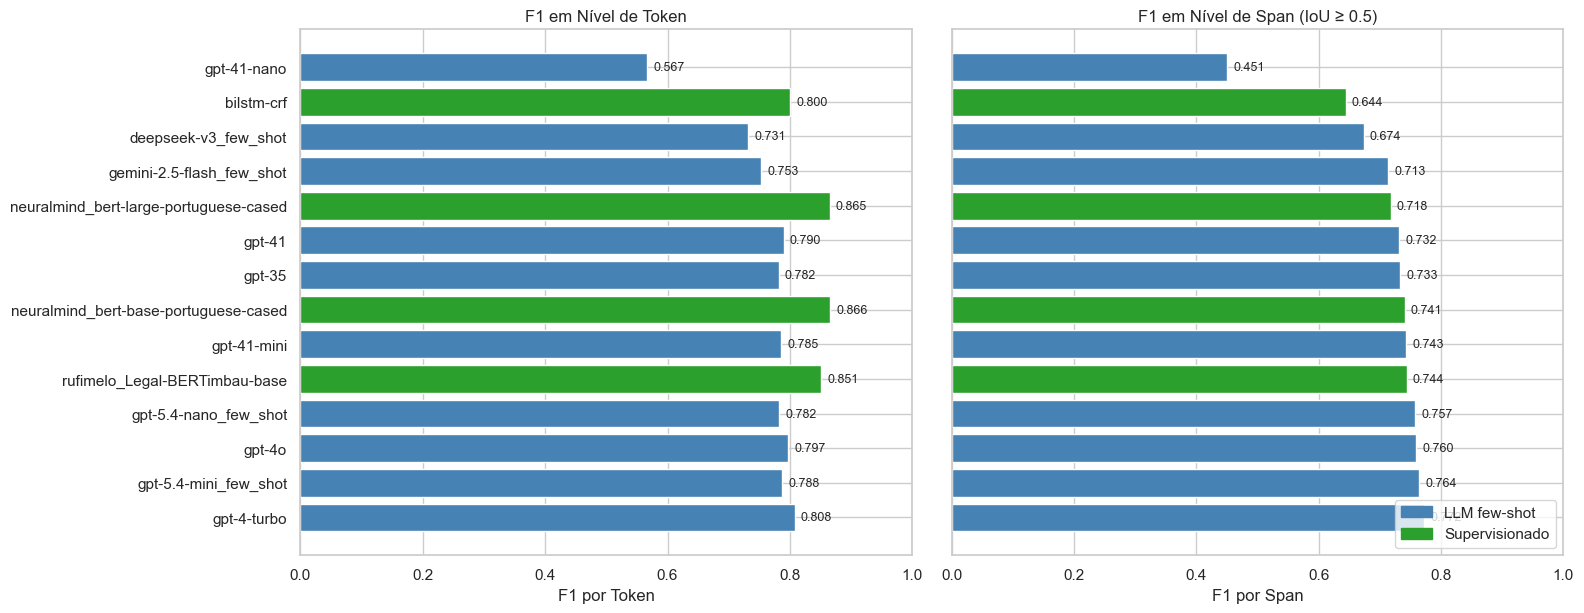

In [20]:
import os
df_plot = df_fewshot.copy()
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, len(df_plot) * 0.45)), sharey=True)

colors = df_plot['paradigm'].map({'supervised': '#2ca02c', 'few-shot': 'steelblue'}).values

axes[0].barh(df_plot['model'], df_plot['token_f1'], color=colors)
axes[0].set_xlabel('F1 por Token')
axes[0].set_title('F1 em Nível de Token')
axes[0].set_xlim(0, 1)
for i, v in enumerate(df_plot['token_f1']):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

axes[1].barh(df_plot['model'], df_plot['span_f1'], color=colors)
axes[1].set_xlabel('F1 por Span')
axes[1].set_title('F1 em Nível de Span (IoU ≥ 0.5)')
axes[1].set_xlim(0, 1)
for i, v in enumerate(df_plot['span_f1']):
    axes[1].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
axes[1].legend(handles=[
    Patch(color='steelblue', label='LLM few-shot'),
    Patch(color='#2ca02c', label='Supervisionado'),
], loc='lower right')

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp1_overall_f1.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.2 Per-Entity Span F1 Heatmap

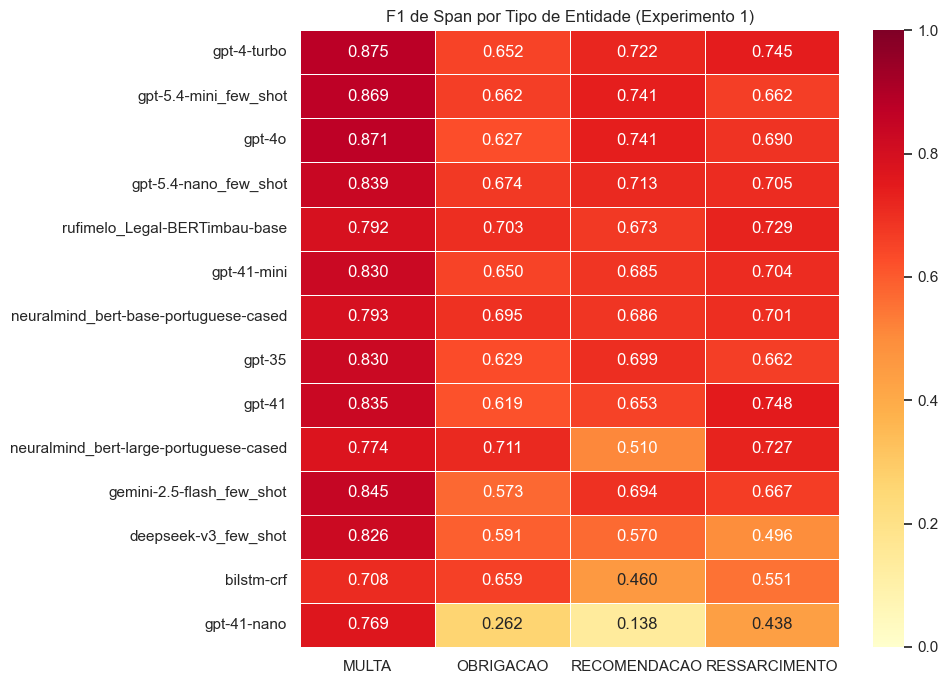

In [21]:
import os
f1_cols = [f'f1_{l}' for l in ENTITY_LABELS if f'f1_{l}' in df_fewshot.columns]
df_entity = df_fewshot[f1_cols].copy()
df_entity.columns = [c.replace('f1_', '') for c in df_entity.columns]
df_entity.index = df_fewshot['model']

fig, ax = plt.subplots(figsize=(10, max(5, len(df_entity) * 0.5)))
sns.heatmap(df_entity, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax,
            linewidths=0.5, vmin=0, vmax=1)
ax.set_title('F1 de Span por Tipo de Entidade (Experimento 1)')
ax.set_ylabel('')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp1_entity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.3 Precision vs Recall Scatter

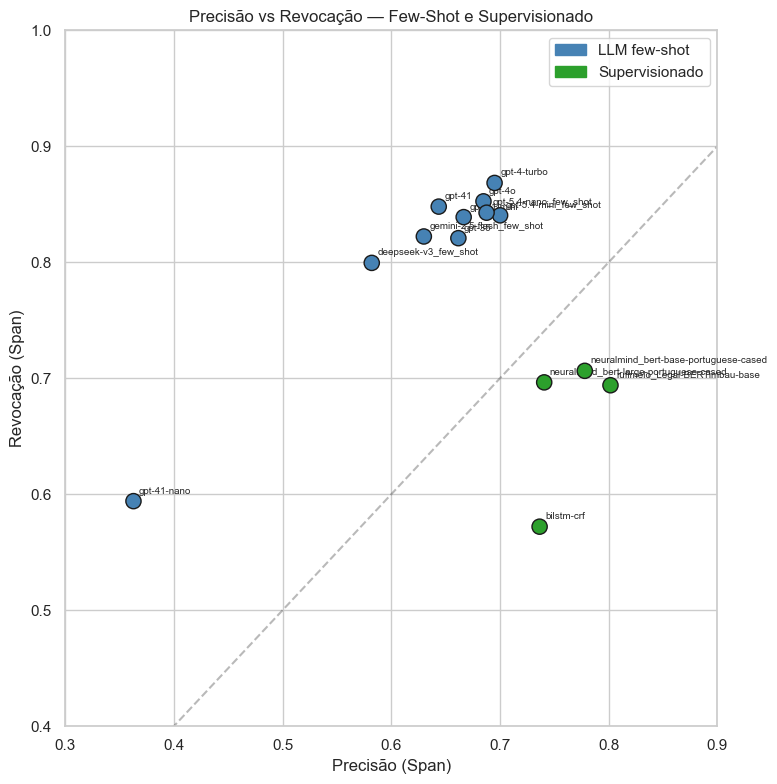

In [22]:
import os
fig, ax = plt.subplots(figsize=(8, 8))

paradigm_colors = df_fewshot['paradigm'].map({'supervised': '#2ca02c', 'few-shot': 'steelblue'})
ax.scatter(df_fewshot['span_precision'], df_fewshot['span_recall'],
           s=120, c=paradigm_colors, edgecolors='k', zorder=5)

for _, row in df_fewshot.iterrows():
    ax.annotate(row['model'], (row['span_precision'], row['span_recall']),
                fontsize=7, ha='left', va='bottom', xytext=(4, 4),
                textcoords='offset points')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax.set_xlabel('Precisão (Span)')
ax.set_ylabel('Revocação (Span)')
ax.set_title('Precisão vs Revocação — Few-Shot e Supervisionado')
ax.set_xlim(0.3, 0.9)
ax.set_ylim(0.4, 1.0)
ax.legend(handles=[
    Patch(color='steelblue', label='LLM few-shot'),
    Patch(color='#2ca02c', label='Supervisionado'),
])
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp1_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

### 1.4 Supervised vs LLM Summary

In [23]:
paradigm_summary = df_fewshot.groupby('paradigm')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
paradigm_summary.columns = ['_'.join(c) for c in paradigm_summary.columns]
display(paradigm_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
paradigm,,,,,,
few-shot,0.7584,0.0708,0.8080,0.7099,0.0956,0.7722
supervised,0.8454,0.0310,0.8658,0.7116,0.0465,0.7440


---
# Experiment 2: Function Calling vs JSON Schema

Impact of the `with_structured_output` method on the same models.
The `few_shot_and_supervised/` results used `function_calling`; the `function_calling_json_schema/` results used the default (json_schema).

In [24]:
print(f'Loading from {FC_JS_DIR}\n')
results_fcjs = load_and_evaluate_directory(FC_JS_DIR, convert_pkl_to_json=False)
df_fcjs = results_to_dataframe(results_fcjs, parse_model_strategy=False)

# Classify method based on suffix and clean model names
df_fcjs['method'] = df_fcjs.index.map(
    lambda x: 'function_calling' if x.endswith('_fc') else 'json_schema')
df_fcjs['model_clean'] = df_fcjs.index.map(
    lambda x: x.replace('_fc', '').replace('_json', '').replace('_few_shot', ''))

df_method_cmp = df_fcjs.sort_values(['model_clean', 'method']).reset_index(drop=True)

display(df_method_cmp[['model_clean', 'method', 'token_f1', 'span_f1',
                        'span_precision', 'span_recall']].round(4))

Loading from dataset\experiments\function_calling_json_schema

  gpt-3.5_few_shot_fc ... token_f1=0.7819  span_f1=0.7328
  gpt-3.5_few_shot_json ... token_f1=0.7332  span_f1=0.6852
  gpt-4o_few_shot_fc ... token_f1=0.7973  span_f1=0.7596
  gpt-4o_few_shot_json ... token_f1=0.7362  span_f1=0.6836
  gpt-5.4-mini_few_shot_fc ... token_f1=0.7879  span_f1=0.7640
  gpt-5.4-mini_few_shot_json ... token_f1=0.5807  span_f1=0.5769
  gpt-5.4-nano_few_shot_fc ... token_f1=0.7820  span_f1=0.7574
  gpt-5.4-nano_few_shot_json ... token_f1=0.7479  span_f1=0.7194


,model_clean,method,token_f1,span_f1,span_precision,span_recall
0,gpt-3.5,function_calling,0.7819,0.7328,0.6618,0.8209
1,gpt-3.5,json_schema,0.7332,0.6852,0.6264,0.7563
2,gpt-4o,function_calling,0.7973,0.7596,0.6849,0.8526
3,gpt-4o,json_schema,0.7362,0.6836,0.6383,0.7358
4,gpt-5.4-mini,function_calling,0.7879,0.7640,0.7002,0.8405
5,gpt-5.4-mini,json_schema,0.5807,0.5769,0.6598,0.5125
6,gpt-5.4-nano,function_calling,0.7820,0.7574,0.6877,0.8428
7,gpt-5.4-nano,json_schema,0.7479,0.7194,0.6699,0.7768


In [25]:
df_method_cmp.to_markdown('dataset/results/experiments/fc_vs_json_schema.md', index=False)

### 2.1 Method Impact — Grouped Bar Chart

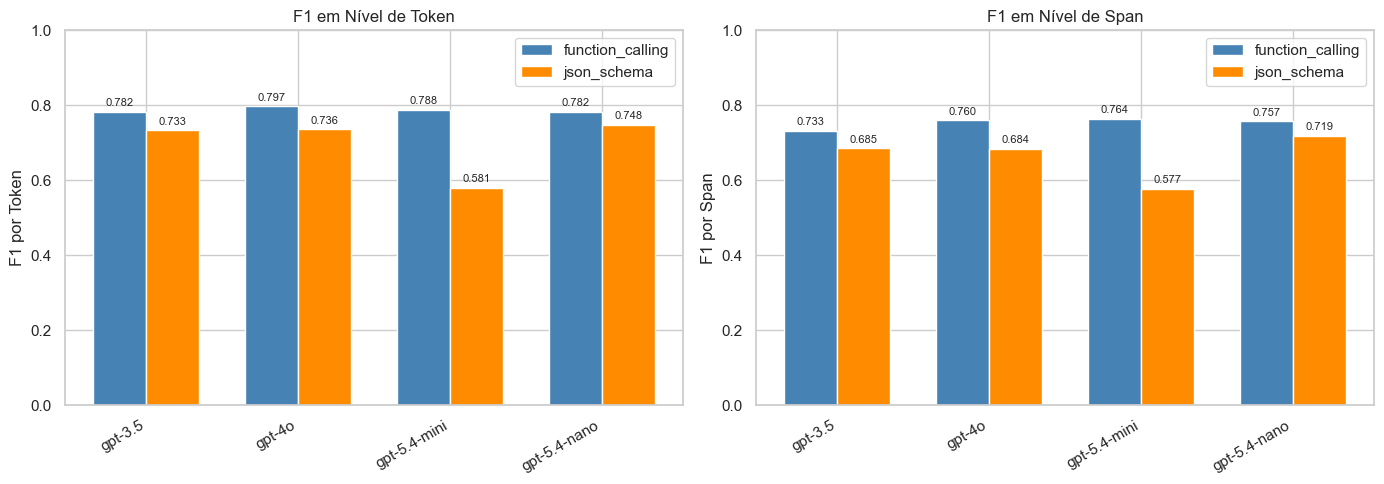

In [26]:
import os
models = sorted(df_method_cmp['model_clean'].unique())
x = np.arange(len(models))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel, title in [
    (axes[0], 'token_f1', 'F1 por Token', 'F1 em Nível de Token'),
    (axes[1], 'span_f1', 'F1 por Span', 'F1 em Nível de Span'),
]:
    fc_vals = [df_method_cmp[(df_method_cmp['model_clean'] == m) & (df_method_cmp['method'] == 'function_calling')][metric].values
              for m in models]
    js_vals = [df_method_cmp[(df_method_cmp['model_clean'] == m) & (df_method_cmp['method'] == 'json_schema')][metric].values
              for m in models]
    fc_vals = [v[0] if len(v) > 0 else 0 for v in fc_vals]
    js_vals = [v[0] if len(v) > 0 else 0 for v in js_vals]

    bars1 = ax.bar(x - width/2, fc_vals, width, label='function_calling', color='steelblue')
    bars2 = ax.bar(x + width/2, js_vals, width, label='json_schema', color='darkorange')
    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=30, ha='right')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.set_ylim(0, 1)

    for bars in [bars1, bars2]:
        for bar in bars:
            if bar.get_height() > 0:
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                        f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp2_method_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 2.2 Delta per Entity

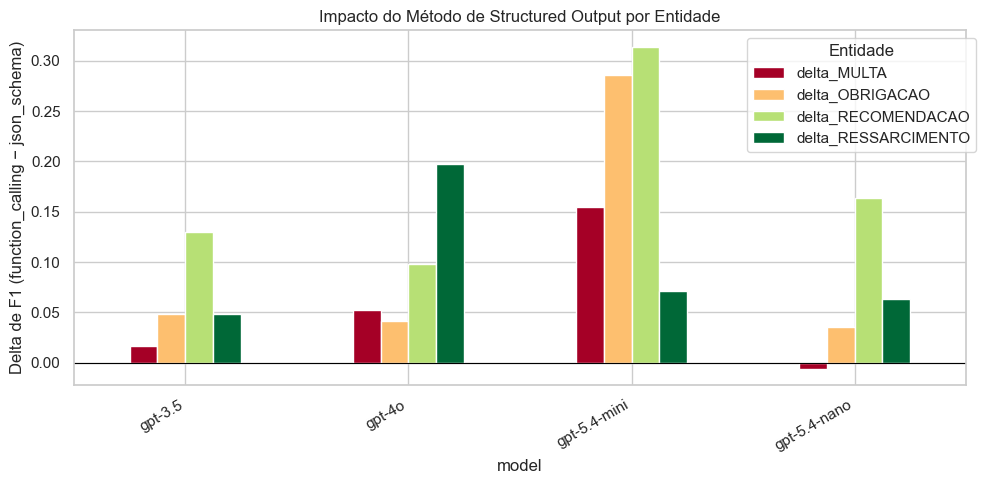

In [27]:
import os
delta_rows = []
for model in models:
    fc_row = df_method_cmp[(df_method_cmp['model_clean'] == model) & (df_method_cmp['method'] == 'function_calling')]
    js_row = df_method_cmp[(df_method_cmp['model_clean'] == model) & (df_method_cmp['method'] == 'json_schema')]
    if len(fc_row) == 0 or len(js_row) == 0:
        continue
    row = {'model': model}
    for label in ENTITY_LABELS:
        col = f'f1_{label}'
        if col in fc_row.columns and col in js_row.columns:
            fc_val = fc_row[col].values[0] if pd.notna(fc_row[col].values[0]) else 0
            js_val = js_row[col].values[0] if pd.notna(js_row[col].values[0]) else 0
            row[f'delta_{label}'] = fc_val - js_val
    delta_rows.append(row)

df_delta = pd.DataFrame(delta_rows).set_index('model')

fig, ax = plt.subplots(figsize=(10, 5))
df_delta.plot(kind='bar', ax=ax, colormap='RdYlGn')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Delta de F1 (function_calling − json_schema)')
ax.set_title('Impacto do Método de Structured Output por Entidade')
ax.legend(title='Entidade', bbox_to_anchor=(1.02, 1))
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp2_delta_per_entity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Experiment 3: Prompt Engineering Techniques

Comparison of prompting strategies: few-shot, two-stage, dynamic few-shot, and self-refinement.

In [28]:
print(f'Loading from {PROMPT_DIR}\n')
results_prompt = load_and_evaluate_directory(PROMPT_DIR, convert_pkl_to_json=False)

Loading from dataset\experiments\prompt_engineering

  deepseek-v3_cot ... token_f1=0.6001  span_f1=0.5299
  deepseek-v3_dynamic_few_shot ... token_f1=0.6758  span_f1=0.5663
  deepseek-v3_few_shot ... token_f1=0.7314  span_f1=0.6737
  deepseek-v3_two_stage ... token_f1=0.7589  span_f1=0.6992
  gemini-2.5-flash_cot ... token_f1=0.7676  span_f1=0.7433
  gemini-2.5-flash_dynamic_few_shot ... token_f1=0.7719  span_f1=0.7106
  gemini-2.5-flash_few_shot ... token_f1=0.7533  span_f1=0.7134
  gemini-2.5-flash_two_stage ... token_f1=0.7708  span_f1=0.7318
  gpt-5.4-mini_cot ... token_f1=0.7863  span_f1=0.7459
  gpt-5.4-mini_dynamic_few_shot ... token_f1=0.7443  span_f1=0.6837
  gpt-5.4-mini_few_shot ... token_f1=0.7879  span_f1=0.7640
  gpt-5.4-mini_two_stage ... token_f1=0.7349  span_f1=0.6837
  gpt-5.4-nano_cot ... token_f1=0.7942  span_f1=0.7710
  gpt-5.4-nano_dynamic_few_shot ... token_f1=0.7376  span_f1=0.7028
  gpt-5.4-nano_few_shot ... token_f1=0.7820  span_f1=0.7574
  gpt-5.4-nano_two_s

In [29]:
df_prompt = results_to_dataframe(results_prompt, parse_model_strategy=False)

# Parse model and technique from filename
techniques = ['dynamic_few_shot', 'two_stage', 'few_shot', 'cot']

def parse_technique(name):
    for tech in techniques:
        if name.endswith(f'_{tech}'):
            model = name[:-(len(tech) + 1)]
            return model, tech
    return name, 'unknown'

parsed = df_prompt.index.map(parse_technique)
df_prompt['model'] = [p[0] for p in parsed]
df_prompt['technique'] = [p[1] for p in parsed]

display(df_prompt[['model', 'technique', 'token_f1', 'span_f1',
                    'span_precision', 'span_recall']].style.format(
    '{:.4f}', subset=['token_f1', 'span_f1', 'span_precision', 'span_recall']
).background_gradient(cmap='YlGn', subset=['span_f1']))

,model,technique,token_f1,span_f1,span_precision,span_recall
experiment,,,,,,
gpt-5.4-nano_cot,gpt-5.4-nano,cot,0.7942,0.7710,0.7154,0.8360
gpt-5.4-mini_few_shot,gpt-5.4-mini,few_shot,0.7879,0.7640,0.7002,0.8405
gpt-5.4-nano_few_shot,gpt-5.4-nano,few_shot,0.7820,0.7574,0.6877,0.8428
gpt-5.4-mini_cot,gpt-5.4-mini,cot,0.7863,0.7459,0.6824,0.8223
gemini-2.5-flash_cot,gemini-2.5-flash,cot,0.7676,0.7433,0.6619,0.8474
gemini-2.5-flash_two_stage,gemini-2.5-flash,two_stage,0.7708,0.7318,0.6507,0.8360
gpt-5.4-nano_two_stage,gpt-5.4-nano,two_stage,0.7545,0.7242,0.6732,0.7836
gemini-2.5-flash_few_shot,gemini-2.5-flash,few_shot,0.7533,0.7134,0.6300,0.8223
gemini-2.5-flash_dynamic_few_shot,gemini-2.5-flash,dynamic_few_shot,0.7719,0.7106,0.6256,0.8223


In [30]:
df_prompt.to_markdown('dataset/results/experiments/prompt_engineering_results.md', index=True)

### 3.1 Technique Comparison — Span F1 by Model × Technique

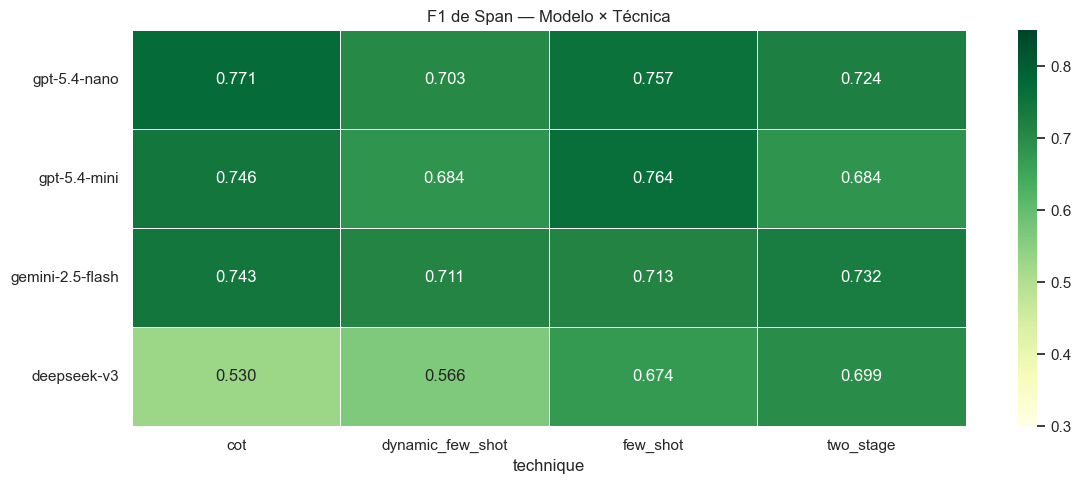

In [31]:
import os
pivot = df_prompt.pivot_table(index='model', columns='technique', values='span_f1')
pivot = pivot.sort_values(pivot.columns.tolist(), ascending=False)

fig, ax = plt.subplots(figsize=(12, max(5, len(pivot) * 0.6)))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='YlGn', ax=ax,
            linewidths=0.5, vmin=0.3, vmax=0.85)
ax.set_title('F1 de Span — Modelo × Técnica')
ax.set_ylabel('')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp3_technique_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Strategy Summary — Mean and Std

In [32]:
strategy_summary = df_prompt.groupby('technique')[['token_f1', 'span_f1']].agg(['mean', 'std', 'max'])
strategy_summary.columns = ['_'.join(c) for c in strategy_summary.columns]
strategy_summary = strategy_summary.sort_values('span_f1_mean', ascending=False)
display(strategy_summary.round(4))

,token_f1_mean,token_f1_std,token_f1_max,span_f1_mean,span_f1_std,span_f1_max
technique,,,,,,
few_shot,0.7636,0.0263,0.7879,0.7271,0.0421,0.7640
two_stage,0.7548,0.0149,0.7708,0.7097,0.0223,0.7318
cot,0.7370,0.0920,0.7942,0.6975,0.1125,0.7710
dynamic_few_shot,0.7324,0.0405,0.7719,0.6659,0.0674,0.7106


In [33]:
strategy_summary.to_markdown('dataset/results/experiments/strategy_summary.md', index=True)

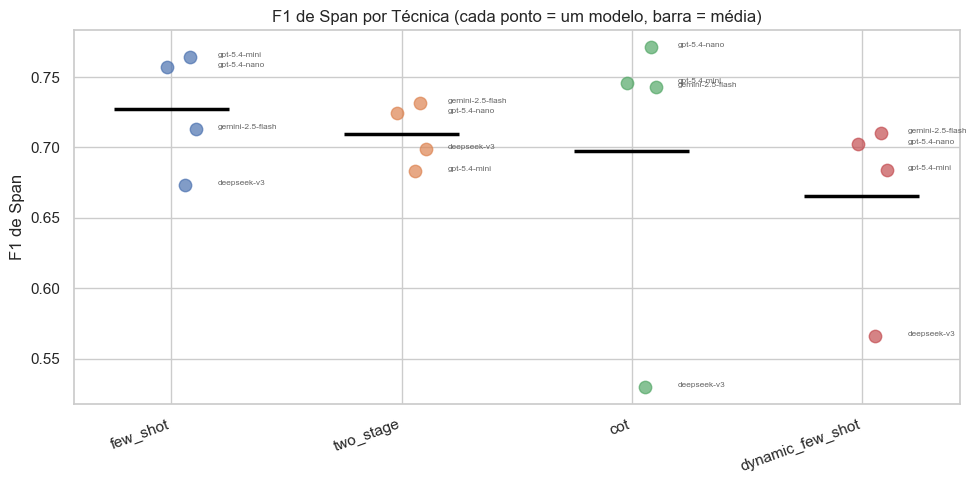

In [34]:
import os
fig, ax = plt.subplots(figsize=(10, 5))
tech_order = strategy_summary.index.tolist()

for i, tech in enumerate(tech_order):
    subset = df_prompt[df_prompt['technique'] == tech]
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, len(subset))
    ax.scatter([i] * len(subset) + jitter, subset['span_f1'], s=80, zorder=5, alpha=0.7)
    ax.hlines(subset['span_f1'].mean(), i - 0.25, i + 0.25, colors='black', linewidth=2.5)

    for _, row in subset.iterrows():
        ax.annotate(row['model'], (i + 0.2, row['span_f1']),
                    fontsize=6, alpha=0.7)

ax.set_xticks(range(len(tech_order)))
ax.set_xticklabels(tech_order, rotation=20, ha='right')
ax.set_ylabel('F1 de Span')
ax.set_title('F1 de Span por Técnica (cada ponto = um modelo, barra = média)')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp3_strategy_dots.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.3 Per-Entity Breakdown by Technique (best model per technique)

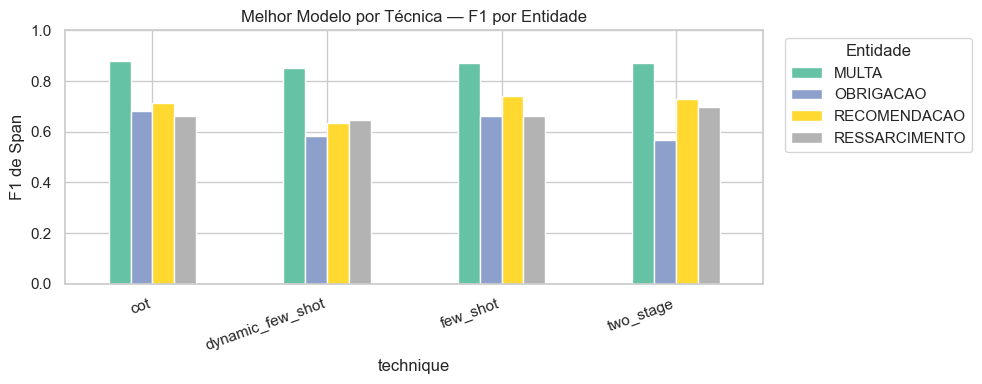

In [35]:
import os
best_per_tech = df_prompt.loc[df_prompt.groupby('technique')['span_f1'].idxmax()]

f1_cols = [f'f1_{l}' for l in ENTITY_LABELS if f'f1_{l}' in best_per_tech.columns]
df_best_entity = best_per_tech.set_index('technique')[f1_cols]
df_best_entity.columns = [c.replace('f1_', '') for c in df_best_entity.columns]

fig, ax = plt.subplots(figsize=(10, 4))
df_best_entity.plot(kind='bar', ax=ax, colormap='Set2')
ax.set_ylabel('F1 de Span')
ax.set_title('Melhor Modelo por Técnica — F1 por Entidade')
ax.legend(title='Entidade', bbox_to_anchor=(1.02, 1))
ax.set_ylim(0, 1)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/exp3_best_per_technique_entity.png', dpi=150, bbox_inches='tight')
plt.show()

---
# Global Summary

Top results across all experiments and key insights.

In [36]:
print('=== TOP 5 — Few-Shot & Supervised (Experiment 1) ===')
display(df_fewshot[['model', 'strategy', 'span_f1', 'token_f1']].head())

print('\n=== BEST per Entity (Experiment 1) ===')
for label in ENTITY_LABELS:
    col = f'f1_{label}'
    if col in df_fewshot.columns:
        best_idx = df_fewshot[col].idxmax()
        print(f'  {label}: {df_fewshot.loc[best_idx, "model"]}  '
              f'({df_fewshot.loc[best_idx, col]:.4f})')

print('\n=== TOP 5 — Prompt Engineering (Experiment 3) ===')
display(df_prompt[['model', 'technique', 'span_f1', 'token_f1']].head())

=== TOP 5 — Few-Shot & Supervised (Experiment 1) ===


,model,strategy,span_f1,token_f1
experiment,,,,
gpt-4-turbo,gpt-4-turbo,few_shot,0.772177,0.807971
gpt-5.4-mini_few_shot,gpt-5.4-mini_few_shot,few_shot,0.763975,0.787871
gpt-4o,gpt-4o,few_shot,0.759596,0.797336
gpt-5.4-nano_few_shot,gpt-5.4-nano_few_shot,few_shot,0.757421,0.782034
rufimelo_Legal-BERTimbau-base__supervised,rufimelo_Legal-BERTimbau-base,supervised,0.744000,0.850670



=== BEST per Entity (Experiment 1) ===
  MULTA: gpt-4-turbo  (0.8750)
  OBRIGACAO: neuralmind_bert-large-portuguese-cased  (0.7113)
  RECOMENDACAO: gpt-5.4-mini_few_shot  (0.7413)
  RESSARCIMENTO: gpt-41  (0.7481)

=== TOP 5 — Prompt Engineering (Experiment 3) ===


,model,technique,span_f1,token_f1
experiment,,,,
gpt-5.4-nano_cot,gpt-5.4-nano,cot,0.771008,0.794152
gpt-5.4-mini_few_shot,gpt-5.4-mini,few_shot,0.763975,0.787871
gpt-5.4-nano_few_shot,gpt-5.4-nano,few_shot,0.757421,0.782034
gpt-5.4-mini_cot,gpt-5.4-mini,cot,0.745868,0.786266
gemini-2.5-flash_cot,gemini-2.5-flash,cot,0.743257,0.767570


---
## Export

In [37]:
df_fewshot.to_excel('exp1_fewshot_supervised_summary.xlsx', index=False)
df_prompt.to_excel('exp3_prompt_engineering_summary.xlsx', index=False)

if len(df_method_cmp) > 0:
    df_method_cmp.to_excel('exp2_method_comparison_summary.xlsx', index=False)

print('Exported:')
print('  exp1_fewshot_supervised_summary.xlsx')
print('  exp2_method_comparison_summary.xlsx')
print('  exp3_prompt_engineering_summary.xlsx')

Exported:
  exp1_fewshot_supervised_summary.xlsx
  exp2_method_comparison_summary.xlsx
  exp3_prompt_engineering_summary.xlsx
